# Frequency resolved topological density

The Berry curvature of the occupied bands is itself an energy integral of an energy-resolved
quantity, $\Omega(\mathbf k)=\int_{-\infty}^{\epsilon_F}\Xi(\mathbf k,\omega)\,d\omega$.
`topology.chern_density` integrates $\Xi(\mathbf k,\omega)$ over the whole Brillouin zone at a set
of energies, giving the frequency-resolved Berry-curvature density `cs` and its cumulative
(energy-integrated) sum `csi`. This is a Green's-function-based estimator, numerically more
delicate than the direct Wilson-loop `h.get_chern()` -- treat it as a qualitative frequency-resolved
profile rather than an exact cross-check. The `es` energy window must clear the *bottom* of the
occupied bands (not just straddle the gap): `csi` is a cumulative integral starting from `es[0]`, so
if `es[0]` sits mid-band instead of below the whole spectrum, the "plateau" is missing whatever
Berry-curvature weight lies below the window.</cell id="cell-00">


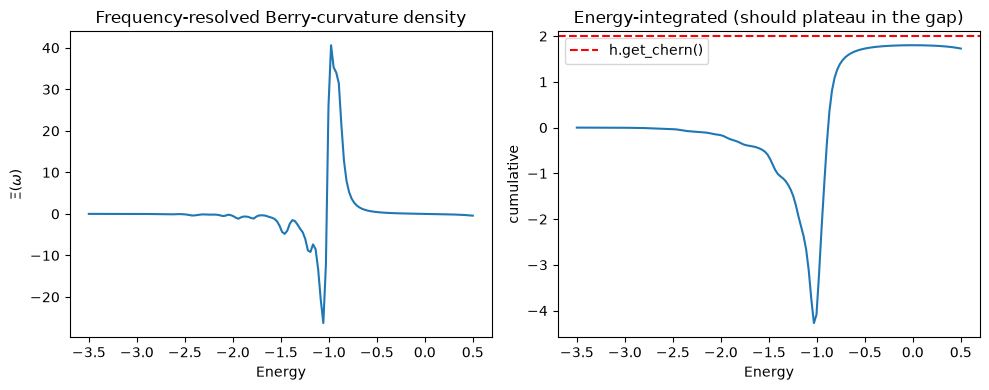

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry
from pyqula import topology
import io, contextlib

g = geometry.honeycomb_lattice()
h = g.get_hamiltonian()
h.add_haldane(0.2) # a larger Haldane mass opens a wider gap, easier to resolve

# the honeycomb nearest-neighbor bandwidth is [-3,3]: the window must start
# below -3 for csi's cumulative integral (which starts at 0 at es[0]) to
# have picked up the full valence band by the time it reaches the gap
with contextlib.redirect_stdout(io.StringIO()): # silence the progress bar
    (es,cs,csi) = topology.chern_density(h,nk=10,delta=0.05,dk=0.05,
            es=np.linspace(-3.5,0.5,150))

fig,axs = plt.subplots(1,2,figsize=(10,4))
axs[0].plot(es,cs)
axs[0].set_xlabel("Energy") ; axs[0].set_ylabel("$\Xi(\omega)$")
axs[0].set_title("Frequency-resolved Berry-curvature density")
axs[1].plot(es,csi)
axs[1].axhline(h.get_chern(nk=20),color="red",ls="--",label="h.get_chern()")
axs[1].set_xlabel("Energy") ; axs[1].set_ylabel("cumulative")
axs[1].set_title("Energy-integrated (should plateau in the gap)")
axs[1].legend()
plt.tight_layout()
plt.show()